In [ ]:
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import geopandas as gpd
from pyspark.sql import SparkSession
from pyspark.sql import Window
import seaborn as sns
import pandas as pd
import numpy as np
import contextily

import sys
sys.path.append('../lib')

In [2]:
from load_netmob import Load_NetMob

df = Load_NetMob([1, 2, 3])

initializing spark session ...
merging datasets ...
merging with trips ...
merging with individuals ...
merging with weather ...


In [3]:
df.remove_blurring()

Remove blurring effect ...


In [4]:
df.data.show(5)

+-------+-----------+----------+-----+-------------------+-----+-------------------+------------+----+-----------+-----------------+--------------------+--------+----------+--------+------------+------------+------------+------------+------+------+--------+--------+--------+---------+-----------+---------+------------+---------------+----------------+----------------+--------------------+--------------+---------------+-----------------+-----------------+-----------------+-----------+-----------+-------------------+--------------------+-------------------+--------------------+-------------------+-------------------+------+------------+---+-------+------------+----+-------------+-----------+-------------+----+----+----+----+
|     ID|   LATITUDE| LONGITUDE|SPEED|     LOCAL DATETIME|VALID|       UTC DATETIME|      fclass|name|index_right| distance_to_road|                 KEY| Day_EMG|  Date_EMG|Day_Type|ID_Trip_Days|Type_Trip_OD|Code_INSEE_O|Code_INSEE_D|Zone_O|Zone_D|  Time_O|  Time_D|D

In [5]:
df.data.count()

4335029

In [6]:
roads = df.data\
  .groupby('index_right')\
  .agg(
    sum('Weight_Day').alias('weight'), 
    first('name').alias('name'), 
    mode('Zone_O').alias('zone'))

In [7]:
paris = roads\
.filter(col('zone') == 'PARIS')\
.orderBy(desc('weight'))\
.show(5)

+-----------+------------------+------------------+-----+
|index_right|            weight|              name| zone|
+-----------+------------------+------------------+-----+
|     201733|  2796317.19793302|  Rue de Montreuil|PARIS|
|     723734| 1790494.848673901|              NULL|PARIS|
|     566656| 1147245.637778015|Allée André Breton|PARIS|
|     729599|1115153.4368625798|              NULL|PARIS|
|     431981|1068496.6420963055|              NULL|PARIS|
+-----------+------------------+------------------+-----+
only showing top 5 rows


In [8]:
zone_window = Window.partitionBy('zone')

roads = roads.withColumn('max', max('weight').over(zone_window))

In [9]:
best_roads = roads.filter(col('weight') == col('max'))

In [10]:
best_roads.show(5, truncate=False)

+-----------+------------------+------------------------+-----+------------------+
|index_right|weight            |name                    |zone |max               |
+-----------+------------------+------------------------+-----+------------------+
|201733     |2796317.19793302  |Rue de Montreuil        |PARIS|2796317.19793302  |
|447037     |4444466.257022827 |NULL                    |OS   |4444466.257022827 |
|849514     |1458819.4357735005|Boulevard Anatole France|IS   |1458819.4357735005|
+-----------+------------------+------------------------+-----+------------------+



In [11]:
road_1_gps = df.data.filter(col('index_right') == 201733).toPandas() # first paris
road_2_gps = df.data.filter(col('index_right') == 447037).toPandas() # OS
road_3_gps = df.data.filter(col('index_right') == 849514).toPandas() # IS
road_4_gps = df.data.filter(col('index_right') == 723734).toPandas() # second paris
road_5_gps = df.data.filter(col('index_right') == 566656).toPandas() # third paris

In [12]:
road_3_gps.head()

,ID,LATITUDE,LONGITUDE,SPEED,LOCAL DATETIME,VALID,UTC DATETIME,fclass,name,index_right,...,PRO_CAT,NBPERS_HOUSE,BIKE,ELECT_SCOOTER,TWO_WHEELER,time_utc,icao,temp,rhum,prcp
0,42_0306,48.915928,2.338404,4.232,2022-10-17 07:19:33,DGPS,2022-10-17 05:19:33,cycleway,Boulevard Anatole France,849514,...,5,1,0,1,1,2022-10-17 05,LFPB,18.0,79.0,0.0
1,42_0306,48.915937,2.338422,3.676,2022-10-17 07:19:34,DGPS,2022-10-17 05:19:34,cycleway,Boulevard Anatole France,849514,...,5,1,0,1,1,2022-10-17 05,LFPB,18.0,79.0,0.0
2,42_0306,48.915944,2.338432,3.759,2022-10-17 07:19:35,DGPS,2022-10-17 05:19:35,cycleway,Boulevard Anatole France,849514,...,5,1,0,1,1,2022-10-17 05,LFPB,18.0,79.0,0.0
3,42_0306,48.915953,2.338445,4.720,2022-10-17 07:19:36,DGPS,2022-10-17 05:19:36,cycleway,Boulevard Anatole France,849514,...,5,1,0,1,1,2022-10-17 05,LFPB,18.0,79.0,0.0
4,42_0306,48.915963,2.338471,4.045,2022-10-17 07:19:37,DGPS,2022-10-17 05:19:37,cycleway,Boulevard Anatole France,849514,...,5,1,0,1,1,2022-10-17 05,LFPB,18.0,79.0,0.0


In [13]:
road_1_geo = gpd.GeoDataFrame(road_1_gps, 
                      geometry=gpd.points_from_xy(road_1_gps['LONGITUDE'], 
                                                  road_1_gps['LATITUDE']), 
                      crs=4326).to_crs(epsg=3857)
road_2_geo = gpd.GeoDataFrame(road_2_gps, 
                      geometry=gpd.points_from_xy(road_2_gps['LONGITUDE'], 
                                                  road_2_gps['LATITUDE']), 
                      crs=4326).to_crs(epsg=3857)
road_3_geo = gpd.GeoDataFrame(road_3_gps, 
                      geometry=gpd.points_from_xy(road_3_gps['LONGITUDE'], 
                                                  road_3_gps['LATITUDE']), 
                      crs=4326).to_crs(epsg=3857)
road_4_geo = gpd.GeoDataFrame(road_4_gps, 
                      geometry=gpd.points_from_xy(road_4_gps['LONGITUDE'], 
                                                  road_4_gps['LATITUDE']), 
                      crs=4326).to_crs(epsg=3857)
road_5_geo = gpd.GeoDataFrame(road_5_gps, 
                      geometry=gpd.points_from_xy(road_5_gps['LONGITUDE'], 
                                                  road_5_gps['LATITUDE']), 
                      crs=4326).to_crs(epsg=3857)

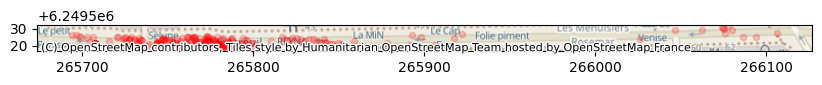

In [ ]:
ax = road_1_geo.plot(markersize=20, alpha=0.2, color='red', figsize=(10, 10))
contextily.add_basemap(ax=ax)

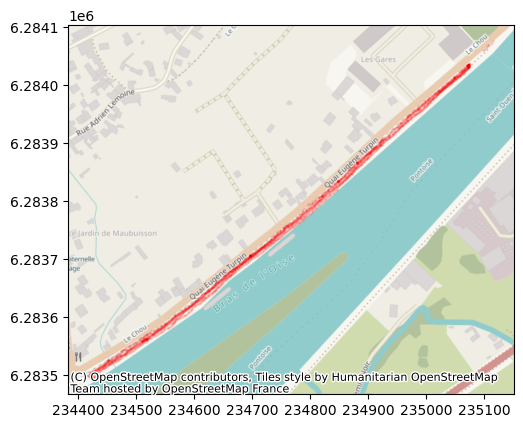

In [15]:
ax = road_2_geo.plot(markersize=1, alpha=0.09, color='red')
contextily.add_basemap(ax=ax)

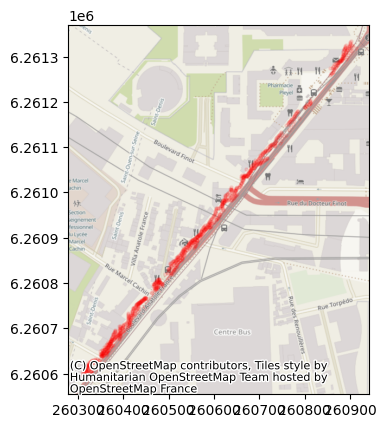

In [16]:
ax = road_3_geo.plot(markersize=5, alpha=0.1, color='red')
contextily.add_basemap(ax=ax)

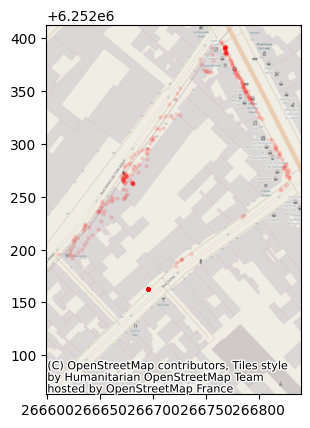

In [ ]:
ax = road_4_geo.plot(markersize=5, alpha=0.1, color='red')
contextily.add_basemap(ax=ax)

c:\Users\yahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


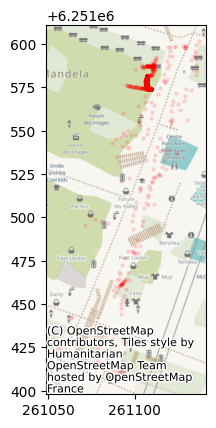

In [18]:
ax = road_5_geo.plot(markersize=5, alpha=0.1, color='red')
contextily.add_basemap(ax=ax)

In [ ]:
# Save to CSVs to use in Kepler.gl
road_1_geo.to_csv('../data/road1.csv') # first paris
road_2_geo.to_csv('../data/road2.csv') # OS
road_3_geo.to_csv('../data/road3.csv') # IS
road_4_geo.to_csv('../data/road4.csv') # second paris
road_5_geo.to_csv('../data/road5.csv') # third paris